<a href="https://colab.research.google.com/github/Jeevesh-Bisht/CSE_INTERNSHIP_NVIDIA-20241CSN0029/blob/main/intel_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.5594 - loss: 1.0957 - val_accuracy: 0.6764 - val_loss: 0.8084
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7132 - loss: 0.7711 - val_accuracy: 0.7470 - val_loss: 0.6568
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7788 - loss: 0.6023 - val_accuracy: 0.8026 - val_loss: 0.5347
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8140 - loss: 0.5107 - val_accuracy: 0.8215 - val_loss: 0.4880
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8333 - loss: 0.4623 - val_accuracy: 0.8361 - val_loss: 0.4650
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8620 - loss: 0.3834 - val_accuracy: 0.8150 - val_loss: 0.5030
Epoch 7/15
351/351 ━━━━━━━━━━━━━

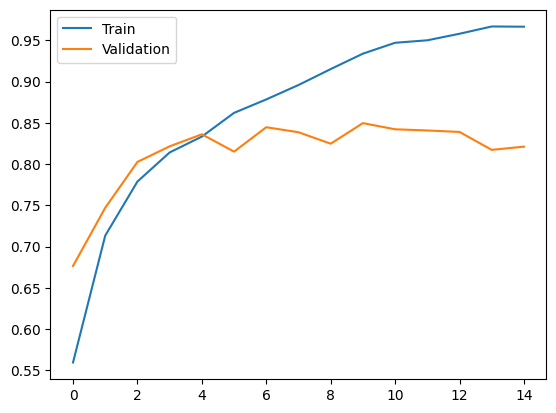

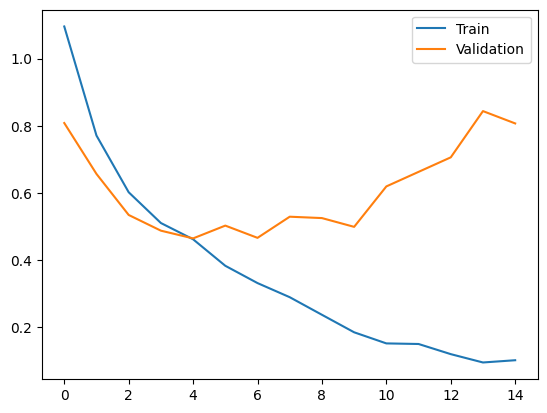

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import zipfile
import os

for file in ["seg_train.zip", "seg_test.zip", "seg_pred.zip"]:
    if os.path.exists(file):
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall("intel_dataset")

possible_train_paths = [
    "intel_dataset/seg_train/seg_train",
    "intel_dataset/seg_train",
    "seg_train/seg_train",
    "seg_train"
]

possible_test_paths = [
    "intel_dataset/seg_test/seg_test",
    "intel_dataset/seg_test",
    "seg_test/seg_test",
    "seg_test"
]

train_path = None
test_path = None

for path in possible_train_paths:
    if os.path.exists(path):
        train_path = path
        break

for path in possible_test_paths:
    if os.path.exists(path):
        test_path = path
        break

if train_path is None or test_path is None:
    print("Dataset folders not found.")
    for root, dirs, files in os.walk("."):
        print(root)
    raise Exception("Fix dataset path.")

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.show()

model.save("intel_image_classifier.h5")